In [76]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('churn dataset.csv')

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.shape

(7043, 21)

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [15]:
columns_to_keep = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'Contract', 'TotalCharges', 'Churn']

df = df[columns_to_keep]

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,Month-to-month,29.85,No
1,Male,0,No,No,34,Yes,No,One year,1889.5,No
2,Male,0,No,No,2,Yes,No,Month-to-month,108.15,Yes
3,Male,0,No,No,45,No,No phone service,One year,1840.75,No
4,Female,0,No,No,2,Yes,No,Month-to-month,151.65,Yes


In [17]:
# binary_columns = ['Partner', 'Dependents', 'PhoneService', 'Churn']

# df[binary_columns] = df[binary_columns].replace({'Yes' : 1, 'No' : 0})

#df.head()

In [18]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'Contract', 'Churn']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,29.85,0
1,1,0,0,0,34,1,0,1,1889.5,0
2,1,0,0,0,2,1,0,0,108.15,1
3,1,0,0,0,45,0,1,1,1840.75,0
4,0,0,0,0,2,1,0,0,151.65,1


# SPLIT THE DATASET INTO TRAINING AND TESTING SETS 

In [20]:
x = df.drop('Churn', axis = 1)
y = df['Churn']

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [23]:
x_train


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges
2142,0,0,0,1,21,1,0,1,1336.8
1623,0,0,0,0,54,1,2,2,5129.45
6074,1,0,1,0,1,0,1,0,23.45
1362,1,0,0,0,4,1,0,0,237.95
6754,1,0,0,1,0,1,2,2,
...,...,...,...,...,...,...,...,...,...
3772,1,0,1,0,1,1,0,0,95
5191,0,0,1,1,23,1,2,2,2198.3
5226,1,0,1,1,12,1,0,0,306.05
5390,1,1,0,0,12,1,2,0,1200.15


In [24]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges
185,0,0,1,0,1,0,1,0,24.8
2715,1,0,0,0,41,1,2,0,996.45
3825,0,0,1,1,52,1,0,2,1031.7
1807,0,0,0,0,1,1,0,0,76.35
132,1,0,0,0,67,1,0,2,3260.1
...,...,...,...,...,...,...,...,...,...
6366,0,0,1,0,64,1,0,2,4378.8
315,1,0,1,1,51,1,2,1,5686.4
2439,1,0,1,1,17,1,0,1,329.75
5002,0,0,1,1,69,0,1,2,2960.1


In [25]:
y_train.head(20)

2142    0
1623    0
6074    1
1362    1
6754    0
1212    0
2722    0
4006    0
6791    1
5466    0
5852    1
4195    0
4166    0
5234    0
3414    0
1803    0
6203    0
5285    0
1323    0
5666    0
Name: Churn, dtype: int64

In [26]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

In [27]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         5634 non-null   int64 
 1   SeniorCitizen  5634 non-null   int64 
 2   Partner        5634 non-null   int64 
 3   Dependents     5634 non-null   int64 
 4   tenure         5634 non-null   int64 
 5   PhoneService   5634 non-null   int64 
 6   MultipleLines  5634 non-null   int64 
 7   Contract       5634 non-null   int64 
 8   TotalCharges   5634 non-null   object
dtypes: int64(8), object(1)
memory usage: 440.2+ KB


In [28]:
x_train['TotalCharges'] = pd.to_numeric(x_train['TotalCharges'], errors = 'coerce')
x_test['TotalCharges'] = pd.to_numeric(x_test['TotalCharges'], errors = 'coerce')

In [29]:
x_train.isnull().sum()

gender            0
SeniorCitizen     0
Partner           0
Dependents        0
tenure            0
PhoneService      0
MultipleLines     0
Contract          0
TotalCharges     10
dtype: int64

In [ ]:
x_train['TotalCharges'].fillna(x_train['TotalCharges'].mean(), inplace = True)
x_test['TotalCharges'].fillna(x_train['TotalCharges'].mean(), inplace = True)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
x_train

array([[-1.02516569, -0.4377492 , -0.96957859, ..., -1.00053704,
         0.37290835, -0.42210502],
       [-1.02516569, -0.4377492 , -0.96957859, ...,  1.10833901,
         1.5775905 ,  1.25536015],
       [ 0.97545208, -0.4377492 ,  1.03137591, ...,  0.05390099,
        -0.83177379, -1.00299144],
       ...,
       [ 0.97545208, -0.4377492 ,  1.03137591, ..., -1.00053704,
        -0.83177379, -0.87799925],
       [ 0.97545208,  2.28441306, -0.96957859, ...,  1.10833901,
        -0.83177379, -0.48254445],
       [ 0.97545208, -0.4377492 , -0.96957859, ..., -1.00053704,
         0.37290835, -0.81110232]], shape=(5634, 9))

# Logistic Regression Algorithms

In [34]:
from sklearn.linear_model import LogisticRegression

In [36]:
LR = LogisticRegression()
LR.fit(x_train,y_train)
y_pred = LR.predict(x_test)

In [37]:
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [39]:
from sklearn.metrics import accuracy_score , classification_report
accuracy_score(y_test, y_pred)

0.7757274662881476

In [40]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.81      0.91      0.86      1036\n           1       0.62      0.39      0.48       373\n\n    accuracy                           0.78      1409\n   macro avg       0.71      0.65      0.67      1409\nweighted avg       0.76      0.78      0.76      1409\n'

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,29.85,0
1,1,0,0,0,34,1,0,1,1889.5,0
2,1,0,0,0,2,1,0,0,108.15,1
3,1,0,0,0,45,0,1,1,1840.75,0
4,0,0,0,0,2,1,0,0,151.65,1


# Rendom forest Algorithm

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
RF_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
RF_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
y_pred_RF = RF_model.predict(x_test)

In [45]:
y_pred_RF

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [46]:
accuracy_score(y_test, y_pred_RF)

0.7608232789212207

# support Vector Machine (SVM)

In [48]:
from sklearn.svm import SVC

In [49]:
svm_model = SVC(kernel = 'linear')
svm_model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [50]:
y_pred_svm = svm_model.predict(x_test)

In [51]:
y_pred_svm

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [53]:
accuracy_score(y_test, y_pred_svm) *100

77.78566359119942

# Compare the all Model

--- Model Comparison Table ---
              Model  Accuracy (%)
Logistic Regression     77.572747
      Random Forest     76.082328
                SVM     77.785664


<Axes: xlabel='Model'>

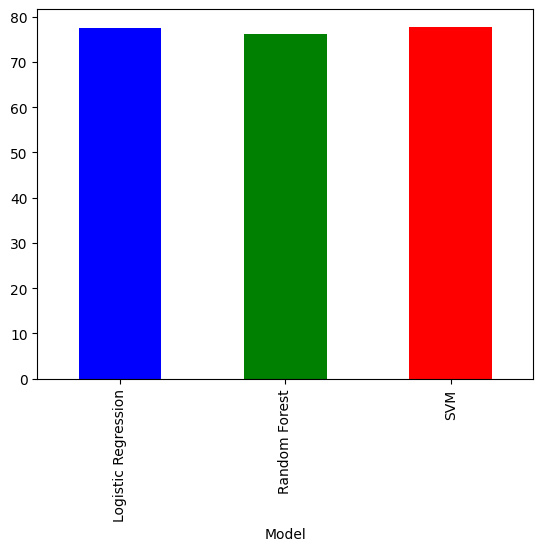

In [58]:

data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy (%)': [
        accuracy_score(y_test, y_pred) * 100,
        accuracy_score(y_test, y_pred_RF) * 100,
        accuracy_score(y_test, y_pred_svm) * 100
    ]
}

comparison_df = pd.DataFrame(data)

print("--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

comparison_df.plot(kind='bar', x='Model', y='Accuracy (%)', color=['blue', 'green', 'red'], legend=False)

# Save the Model.

In [60]:
import pickle
pickle.dump(LR,open('LogisticRegression_model.pkl','wb'))

In [62]:
pickle.dump(RF_model,open('RandomForest_model.pkl', 'wb'))

In [63]:
pickle.dump(svm_model,open('SVM_model.pkl', 'wb'))

In [66]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,29.85,0
1,1,0,0,0,34,1,0,1,1889.5,0
2,1,0,0,0,2,1,0,0,108.15,1
3,1,0,0,0,45,0,1,1,1840.75,0
4,0,0,0,0,2,1,0,0,151.65,1
...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,1,1990.5,0
7039,0,0,1,1,72,1,2,1,7362.9,0
7040,0,0,1,1,11,0,1,0,346.45,0
7041,1,1,1,0,4,1,2,0,306.6,1


# Classification Systems

In [148]:
def predictive(gender, SeniorCitizen, Partner,Dependents, tenure, Phoneservice, Multiline, Contract, TotalCharge):
    data = {
        'gender' : [gender],
        'SeniorCitizen' : [SeniorCitizen],
        'Partner' : [Partner],
        'Dependents' : [Dependents],
        'tenure' : [tenure], 
       'Phoneservice' : [Phoneservice],
        'Multiline' : [Multiline],
        'Contract' : [Contract],
       'TotalCharge' : [TotalCharge]
    }
    df1 = pd.DataFrame(data)


    categorical_columns = ['gender', 'SeniorCitizen', 'Partner','Dependents', 'tenure', 'Phoneservice', 'Multiline', 'Contract', 'TotalCharge']
    for column in categorical_columns:
        df1[column] = label_encoder.transform(df1[column])

        df1 = scaler.transform(df1)
        result = LR.predict(df1).reshape(1,-1)
        return result[0]

In [152]:
gender = 'female'
SeniorCitizen = 'No'
Partner = 'No'
Dependents = 'No'
tenure = '1'
Phoneservice = 'N0'
Multiline = 'No phone service'
Contract = 'Month-to-month'
TotalCharge = 29.85

result = {'Yes': 1, 'No': 0, 'female': 0, 'male': 1, 'Month-to-month': 0, 'One year': 1, 'Two year': 29.85}

if result == 0:
    print('Not Churn')
else:
    print('Churn')

Churn
